In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from dotenv import load_dotenv
import os
load_dotenv()

True

In [18]:
dataset = os.getenv('DATASET_PATH')
df = pd.read_csv(dataset)

In [19]:
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


### Basic statistics of the data

In [20]:
df.isna().sum()

Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

In [21]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


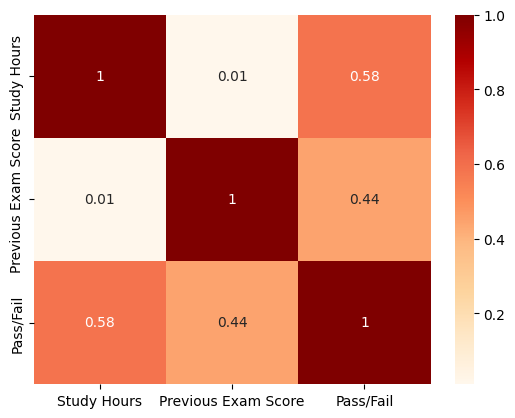

In [22]:
# Correlation between independent and dependent variables

corr = df.corr()
sns.heatmap(corr, annot=True, cmap = "OrRd")
plt.show()

From the above graph, we can see that study hours has a good correlation with Pass/Fail category as it make sense too. Previous Exam score may also determine that a student passes the exam or fails the exam

# EDA

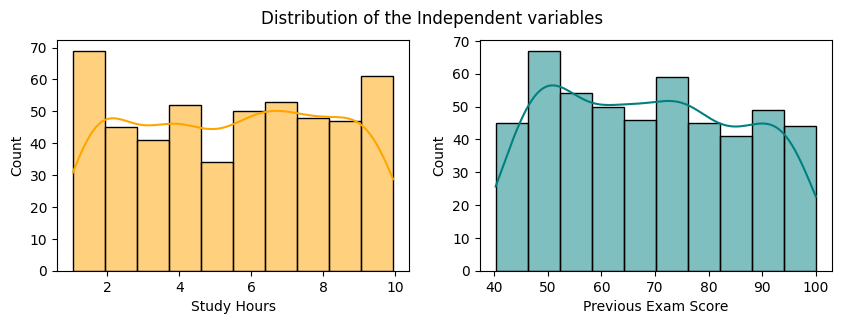

In [23]:
# Distribution of Independent variables

cols = ['Study Hours', 'Previous Exam Score']
colors = ['orange', 'teal']
fig, axes = plt.subplots(1, 2, figsize = (10, 3))
fig.suptitle("Distribution of the Independent variables")
sns.histplot(df[cols[0]], ax = axes[0], kde=True, color = colors[0])
sns.histplot(df[cols[1]], ax = axes[1], kde=True, color = colors[1])
plt.show()

As we can see, for both the variables we are almost having the same distribution so we can continue with further analysis

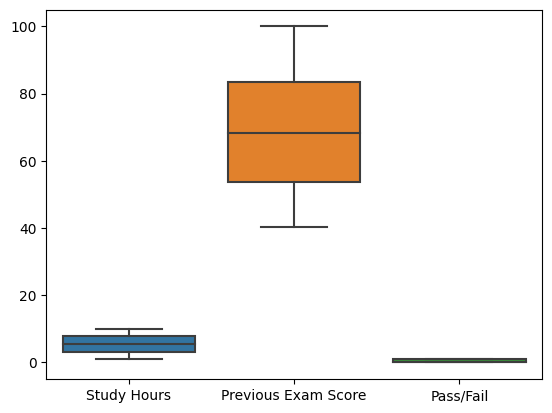

In [24]:
# Let's check for the outliers in our dataset
sns.boxplot(data=df)
plt.show()

The data is pretty much cleaned and free of outliers

# Train Test split and Model building

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Pass/Fail', axis = 1)

y = df['Pass/Fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Saving the scaler model

import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [28]:
# Code for evaluation of different models

from sklearn.metrics import accuracy_score

def evaluate_models(models, X_train, y_train, X_test, y_test):
    """
    Evaluate multiple models on a given dataset.

    Parameters:
    - models: List of tuples containing (model_name, model_instance)
    - X_train, y_train: Training data and labels
    - X_test, y_test: Testing data and labels

    Prints the accuracy for each model on the testing set.
    """
    for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{name}: Accuracy = {accuracy:.4f}")

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = [
    ("Logistic Regression", LogisticRegression()),
    ("Random Forest", RandomForestClassifier()),
    ("AdaBoost", AdaBoostClassifier()),
    ("SVC", SVC()),
    ("XGBoost", XGBClassifier()),
]

evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)

Logistic Regression: Accuracy = 0.8600
Random Forest: Accuracy = 0.9900
AdaBoost: Accuracy = 0.9900
SVC: Accuracy = 0.9500
XGBoost: Accuracy = 0.9800


### From the above models AdaBoost is having minimum error so we can use AdaBoost regressor

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
import warnings
warnings.filterwarnings("ignore")

ada_clf = AdaBoostClassifier()
param = {
    'n_estimators': [50, 100, 150, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
}

clf = GridSearchCV(ada_clf, param, cv=5, scoring='accuracy', verbose=1, n_jobs = 5)
 
clf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=5,
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5],
                         'n_estimators': [50, 100, 150, 200, 300, 500]},
             scoring='accuracy', verbose=1)

In [31]:
print(f'Best parameters: {clf.best_params_}, Best Score: {clf.best_score_:.2f}')

Best parameters: {'learning_rate': 0.01, 'n_estimators': 50}, Best Score: 1.00


In [32]:
# Testing the model with the above parameters

from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test_scaled)
acc_score = accuracy_score(y_pred, y_test)
print(f'Accuracy Score {acc_score}')

Accuracy Score 0.99


In [33]:
ones = (df[df['Pass/Fail'] == 1])
zeros = (df[df['Pass/Fail'] == 0])

percentage_ones = len(ones) / (len(ones) + len(zeros)) * 100
percentage_zeros = len(zeros) / (len(ones) + len(zeros)) * 100

print(f'Percentage of ones: {percentage_ones}%')
print(f'Percentage of zeros: {percentage_zeros}%')

Percentage of ones: 36.8%
Percentage of zeros: 63.2%


In [39]:
from sklearn.linear_model import LogisticRegression

rcf = LogisticRegression(penalty = 'l1', solver = 'liblinear')

rcf.fit(X_train_scaled, y_train)

y_pred = rcf.predict(X_test_scaled)

acc_score = accuracy_score(y_pred, y_test)

print(f'Accuracy Score {acc_score}')

Accuracy Score 0.85


In [40]:
scpre = rcf.predict_proba([[2, 30]])[:,1]
print(scpre)

[1.]


Now we can store this model in the pickle file which will be used for predicting the answers in the streaamlit app

In [36]:
with open('model.pkl', 'wb') as file:
    pickle.dump(clf, file)

----------------------------------------------------- End of notebook ---------------------------------------------------------------